Section 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)

Section 2: Load Dataset

In [2]:
df = pd.read_excel("../data/raw/road_accident_data.xlsx")

print(df.shape)
df.head()

(5771, 22)


,Accident_ID,Accident_Date,Accident_Time,Report_Timestamp,District,Road_Type,Weather_Condition,Surface_Condition,Light_Condition,Traffic_Density,Vehicle_Type,Driver_Age,Driver_Gender,Alcohol_Involved,Vehicle_Speed_kmph,Helmet_Used,Seatbelt_Used,Cause_Category,Accident_Severity,Casualties_Count,Injury_Type,Emergency_Response_Time_Min
0,KER_ACC_100000,2023-04-25,00:47:00,2023-04-25 02:02:00,Kozhikode,Bridge,Clear,Dry,Night,Medium,Truck,23.0,Male,No,90,Not Applicable,No,Drunk Driving,Minor,1,No Injury,6.0
1,NaN,2024-06-01,19:01:00,2024-06-01 21:29:00,Alappuzha,Urban Road,Clear,NaN,Night,Medium,Motorcycle,32.0,NaN,No,58,Yes,Not Applicable,Mechanical Failure,Minor,1,No Injury,13.0
2,KER_ACC_100002,2025-04-05,05:44:00,2025-04-05 07:37:00,Kannur,Rural Road,Clear,Wet,Night,Low,Car,24.0,Female,Yes,54,Not Applicable,Yes,Mechanical Failure,Serious,1,Minor Injury,13.0
3,KER_ACC_100003,2023-09-28,01:46:00,2023-09-28 03:48:00,Malappuram,Junction,Clear,Dry,Night,Medium,Car,53.0,Female,No,32,Not Applicable,Yes,NaN,Minor,2,Minor Injury,25.0
4,KER_ACC_100004,2023-07-16,22:04:00,2023-07-16 22:20:00,Malappuram,Highway,Fog,Dry,Night,NaN,Car,32.0,Female,No,112,NaN,Yes,Weather Conditions,Serious,2,Major Injury,22.0


Section 3: Create Working Copy

In [3]:
df_clean = df.copy()

Section 4: Check Current Data Types

In [4]:
df_clean.dtypes

Accident_ID                               str
Accident_Date                  datetime64[us]
Accident_Time                             str
Report_Timestamp               datetime64[us]
District                                  str
Road_Type                                 str
Weather_Condition                         str
Surface_Condition                         str
Light_Condition                           str
Traffic_Density                           str
Vehicle_Type                              str
Driver_Age                            float64
Driver_Gender                             str
Alcohol_Involved                          str
Vehicle_Speed_kmph                      int64
Helmet_Used                               str
Seatbelt_Used                             str
Cause_Category                            str
Accident_Severity                         str
Casualties_Count                        int64
Injury_Type                               str
Emergency_Response_Time_Min       

Section 5: Convert Date Columns

In [5]:
df_clean['Accident_Date'] = pd.to_datetime(
    df_clean['Accident_Date'],
    format='%Y-%m-%d',
    errors='coerce'
)

df_clean['Accident_Time'] = pd.to_datetime(
    df_clean['Accident_Time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.time

df_clean['Report_Timestamp'] = pd.to_datetime(
    df_clean['Report_Timestamp'],
    format='%Y-%m-%d %H:%M:%S',
    errors='coerce'
)

print(df_clean[['Accident_Date',
                'Accident_Time',
                'Report_Timestamp']].dtypes)

Accident_Date       datetime64[us]
Accident_Time               object
Report_Timestamp    datetime64[us]
dtype: object


Section 6: Missing Value Analysis

In [6]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Cause_Category,290,5.025126
Helmet_Used,279,4.834517
Accident_Severity,275,4.765205
Light_Condition,273,4.730549
Emergency_Response_Time_Min,270,4.678565
Injury_Type,262,4.539941
Road_Type,261,4.522613
District,259,4.487957
Accident_ID,256,4.435973
Driver_Gender,255,4.418645


Section 7: Separate Numerical & Categorical Columns

In [7]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

cat_cols = df_clean.select_dtypes(include=['object', 'str']).columns

print("Numerical:", len(num_cols))
print("Categorical:", len(cat_cols))

Numerical: 4
Categorical: 16


Section 8: Missing Value Treatment

In [8]:
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [9]:
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [10]:
df_clean.isnull().sum()

Accident_ID                    0
Accident_Date                  0
Accident_Time                  0
Report_Timestamp               0
District                       0
Road_Type                      0
Weather_Condition              0
Surface_Condition              0
Light_Condition                0
Traffic_Density                0
Vehicle_Type                   0
Driver_Age                     0
Driver_Gender                  0
Alcohol_Involved               0
Vehicle_Speed_kmph             0
Helmet_Used                    0
Seatbelt_Used                  0
Cause_Category                 0
Accident_Severity              0
Casualties_Count               0
Injury_Type                    0
Emergency_Response_Time_Min    0
dtype: int64

Section 9: Duplicate Detection

In [11]:
duplicates = df_clean.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 47


Section 10: Remove Duplicates

In [12]:
df_clean = df_clean.drop_duplicates()

print(df_clean.shape)

(5724, 22)


Section 11: Outlier Detection

In [13]:
outlier_cols = [
    'Driver_Age',
    'Vehicle_Speed_kmph',
    'Casualties_Count',
    'Emergency_Response_Time_Min'
]

In [14]:
outlier_summary = []

for col in outlier_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = len(
        df_clean[
            (df_clean[col] < lower) | (df_clean[col] > upper)
        ]
    )

    outlier_summary.append([col, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Column', 'Outlier_Count']
)

print(outlier_df)

                        Column  Outlier_Count
0                   Driver_Age             14
1           Vehicle_Speed_kmph              0
2             Casualties_Count            654
3  Emergency_Response_Time_Min             79


Section 12: Visualize Outliers

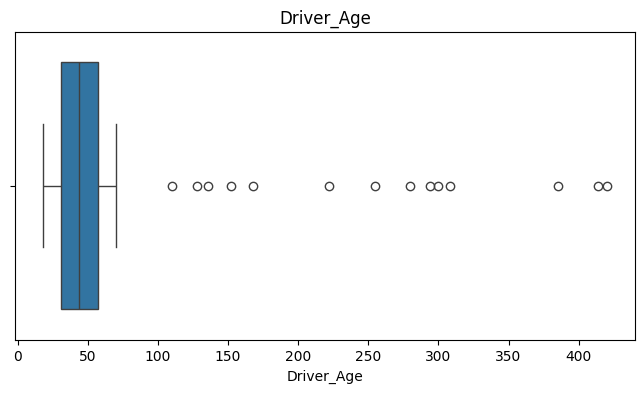

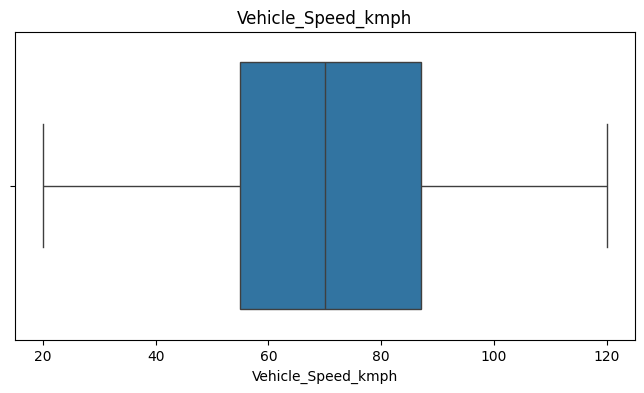

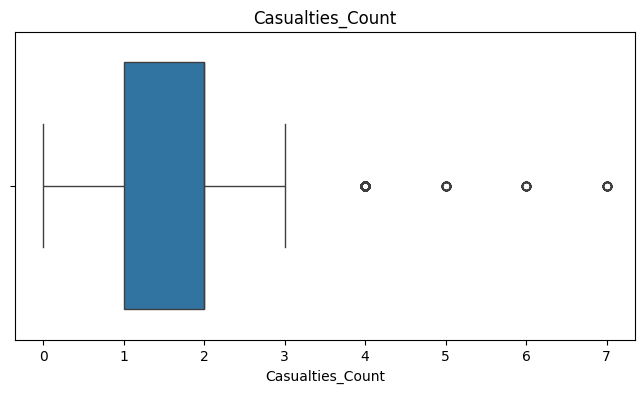

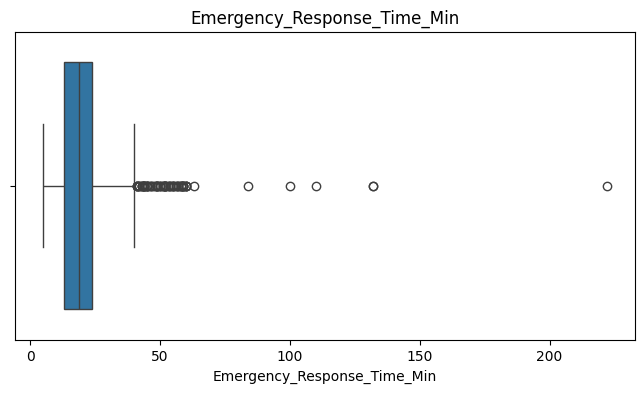

In [15]:
for col in outlier_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df_clean[col])
    plt.title(col)
    plt.show()

Section 13: Outlier Treatment

In [16]:
for col in outlier_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df_clean[col] = np.where(df_clean[col] < lower, lower, df_clean[col])

    df_clean[col] = np.where(df_clean[col] > upper, upper, df_clean[col])

Section 14: Verify Outliers Again

In [17]:
outlier_summary = []

for col in outlier_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = len(
        df_clean[
            (df_clean[col] < lower) | (df_clean[col] > upper)
        ]
    )

    outlier_summary.append([col, count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['Column', 'Outlier_Count']
)

print(outlier_df)

                        Column  Outlier_Count
0                   Driver_Age              0
1           Vehicle_Speed_kmph              0
2             Casualties_Count              0
3  Emergency_Response_Time_Min              0


Section 15: Standardize Categorical Variables

In [18]:
for col in cat_cols:

    df_clean[col] = (df_clean[col].astype(str).str.strip().str.title())

Section 16: Final Data Quality Check

In [19]:
print("Missing Values:", df_clean.isnull().sum().sum())

print("Duplicates:", df_clean.duplicated().sum())

Missing Values: 0
Duplicates: 0


Section 17: Rechecking Data Types

In [20]:
df_clean.dtypes

Accident_ID                               str
Accident_Date                  datetime64[us]
Accident_Time                             str
Report_Timestamp               datetime64[us]
District                                  str
Road_Type                                 str
Weather_Condition                         str
Surface_Condition                         str
Light_Condition                           str
Traffic_Density                           str
Vehicle_Type                              str
Driver_Age                            float64
Driver_Gender                             str
Alcohol_Involved                          str
Vehicle_Speed_kmph                    float64
Helmet_Used                               str
Seatbelt_Used                             str
Cause_Category                            str
Accident_Severity                         str
Casualties_Count                      float64
Injury_Type                               str
Emergency_Response_Time_Min       

Section 18: Fixing Data Types

In [21]:
df_clean['Driver_Age'] = df_clean['Driver_Age'].astype(int)
df_clean['Vehicle_Speed_kmph'] = df_clean['Vehicle_Speed_kmph'].astype(int)
df_clean['Casualties_Count'] = df_clean['Casualties_Count'].astype(int)

<!-- df_clean = df_clean[df_clean['Driver_Age'] <= 90] -->

Section 17: Save Cleaned Dataset

In [23]:
df_clean.to_csv("../data/interim/cleaned_day2.csv", index=False)

<!-- Section 18: Summary -->

Cleaning Actions Performed

1. Converted datetime columns
2. Imputed missing values
3. Removed duplicates
4. Detected outliers using IQR
5. Capped extreme values
6. Standardized categorical variables
7. Saved cleaned dataset